In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
rng = np.random.default_rng(42)
import ipywidgets as widgets
from ipywidgets import interact, interactive_output
from IPython.display import display, Markdown

# Semana 5B — Intervalos de Confianza (Laboratorio)

**Objetivo:** Construir e interpretar intervalos de confianza con datos
meteorológicos reales.  Como tenemos la población completa (~1.08 M registros),
podemos verificar empíricamente la cobertura de los ICs.

**Ejercicios:**

1. IC para la temperatura media mensual
2. Efecto del tamaño de muestra
3. Simulación de cobertura con datos reales
4. ICs por estación del año

In [3]:
df = pd.read_parquet("../data/ClimaLab_2023-05-31_2025-06-20.parquet")

In [4]:
tdb = df["tdb"].dropna()
rh = df["rh"].dropna()
ws = df["ws"].dropna()
mu_tdb = tdb.mean()

---
## 1. IC para la temperatura media mensual

Agrupamos `tdb` por mes calendario y construimos un IC al 95%
para la media de cada mes usando la distribución $t$.

$$\bar{x}_{\text{mes}} \;\pm\; t_{0.025,\;n-1}\;\frac{s_{\text{mes}}}{\sqrt{n_{\text{mes}}}}$$

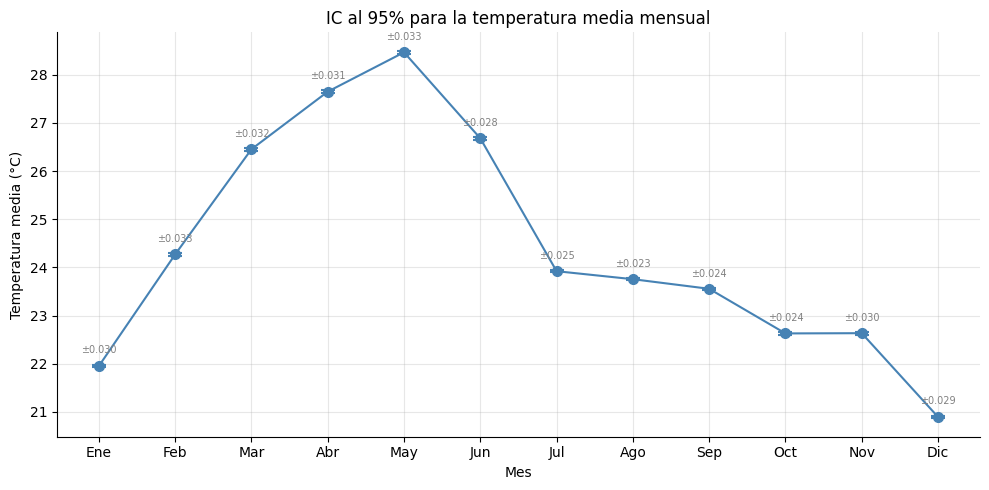

In [5]:
_mensual = tdb.groupby(tdb.index.month)
_meses = range(1, 13)
_nombres = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
            "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

_medias = []
_lo = []
_hi = []
_ns = []

for m in _meses:
    _datos = _mensual.get_group(m).values
    _n = len(_datos)
    _xbar = _datos.mean()
    _s = _datos.std(ddof=1)
    _se = _s / np.sqrt(_n)
    _t_crit = stats.t.ppf(0.975, _n - 1)
    _medias.append(_xbar)
    _lo.append(_xbar - _t_crit * _se)
    _hi.append(_xbar + _t_crit * _se)
    _ns.append(_n)

_medias = np.array(_medias)
_lo = np.array(_lo)
_hi = np.array(_hi)

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.errorbar(
    _meses, _medias,
    yerr=[_medias - _lo, _hi - _medias],
    fmt="o-", color="steelblue", capsize=5, capthick=1.5,
    markersize=7, lw=1.5,
)
ax1.set_xticks(list(_meses))
ax1.set_xticklabels(_nombres)
ax1.set_xlabel("Mes")
ax1.set_ylabel("Temperatura media (°C)")
ax1.set_title("IC al 95% para la temperatura media mensual")

# Anotar anchos
for m, lo, hi in zip(_meses, _lo, _hi):
    ax1.annotate(
        f"±{(hi - lo) / 2:.3f}",
        (m, hi), textcoords="offset points",
        xytext=(0, 8), ha="center", fontsize=7, color="gray",
    )

plt.tight_layout()
plt.show()

> **Observa:**
> - Los ICs son **extremadamente estrechos** (±0.01–0.02 °C) porque
>   $n$ es enorme (~80,000–100,000 registros por mes).
> - Los ICs de enero y julio **no se traslapan** — la diferencia de
>   temperatura entre invierno y verano es estadísticamente significativa
>   (y obvio, pero ahora lo tenemos cuantificado).
> - Incluso meses consecutivos como junio y julio tienen ICs que
>   apenas se traslapan.

---
## 2. Efecto del tamaño de muestra

En la práctica no siempre tenemos millones de datos.
¿Qué pasa con el IC si solo tenemos $n = 10$, 50, 200 o 1000
observaciones de un mismo mes?

### Elige un mes para explorar

In [6]:
mes_slider = widgets.IntSlider(min=1, max=12, step=1, value=7, description="Mes (1=Ene)",
)

def _update(mes_slider):
    _mes = mes_slider
    _nombres = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
    _datos_mes = tdb[tdb.index.month == _mes].values
    _mu_mes = _datos_mes.mean()

    _ns = [10, 50, 200, 1000]

    fig2, ax2 = plt.subplots(figsize=(8, 4))

    for i, _n in enumerate(_ns):
        _muestra = rng.choice(_datos_mes, size=_n, replace=False)
        _xbar = _muestra.mean()
        _s = _muestra.std(ddof=1)
        _se = _s / np.sqrt(_n)
        _t_crit = stats.t.ppf(0.975, _n - 1)
        _margen = _t_crit * _se

        _color = "steelblue"
        ax2.plot([_xbar - _margen, _xbar + _margen], [i, i],
                 color=_color, lw=3)
        ax2.plot(_xbar, i, "o", color=_color, markersize=8, zorder=5)
        ax2.text(_xbar + _margen + 0.05, i,
                 f"  n={_n}  (±{_margen:.2f} °C)", va="center", fontsize=10)

    ax2.axvline(_mu_mes, color="crimson", ls="--", lw=1.5,
                label=f"μ real = {_mu_mes:.2f} °C")
    ax2.set_yticks([])
    ax2.set_xlabel("Temperatura (°C)")
    ax2.set_title(f"IC al 95% — {_nombres[_mes - 1]} — distintos tamaños de muestra")
    ax2.legend()
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(_update, {'mes_slider': mes_slider})
display(widgets.VBox([mes_slider, out]))

> **Conclusiones prácticas:**
> - Con $n = 10$, el IC puede tener ancho de ±2–3 °C — poco útil.
> - Con $n = 1000$, el IC se estrecha a ±0.2–0.3 °C — mucho más informativo.
> - **Pregunta de diseño:** ¿Cuántas mediciones necesito para una
>   precisión de ±0.5 °C?  Respuesta: $n \ge (z \cdot s / 0.5)^2$.

---
## 3. Simulación de cobertura con datos reales

Conocemos la media poblacional real de `tdb`.  Extraemos 200 muestras
de tamaño $n$, construimos ICs al 95% y verificamos cuántos
contienen la media real.

Si la teoría funciona, la cobertura empírica debe ser ~95%.

In [7]:
n_cob_slider = widgets.IntSlider(min=10, max=200, step=10, value=30, description="Tamaño de muestra (n)",
)

def _update(n_cob_slider):
    _n = n_cob_slider
    _k = 200
    _datos = tdb.values

    _medias = np.zeros(_k)
    _lo = np.zeros(_k)
    _hi = np.zeros(_k)
    _cubre = np.zeros(_k, dtype=bool)

    for i in range(_k):
        _muestra = rng.choice(_datos, size=_n, replace=False)
        _xbar = _muestra.mean()
        _s = _muestra.std(ddof=1)
        _se = _s / np.sqrt(_n)
        _t_crit = stats.t.ppf(0.975, _n - 1)
        _margen = _t_crit * _se

        _medias[i] = _xbar
        _lo[i] = _xbar - _margen
        _hi[i] = _xbar + _margen
        _cubre[i] = (_lo[i] <= mu_tdb) & (_hi[i] >= mu_tdb)

    _cobertura = _cubre.mean()

    fig3, ax3 = plt.subplots(figsize=(8, 10))

    for i in range(_k):
        _color = "steelblue" if _cubre[i] else "crimson"
        ax3.plot([_lo[i], _hi[i]], [i, i], color=_color, lw=0.8)

    ax3.axvline(mu_tdb, color="black", ls="--", lw=1.5,
                label=f"μ = {mu_tdb:.2f} °C")

    _n_falla = (~_cubre).sum()
    ax3.set_xlabel("Temperatura (°C)")
    ax3.set_ylabel("# de muestra")
    ax3.set_title(
        f"Cobertura empírica: {_cobertura:.1%}  "
        f"({_n_falla} de {_k} NO contienen μ)  —  n = {_n}"
    )
    ax3.legend(loc="upper right")
    ax3.invert_yaxis()
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(_update, {'n_cob_slider': n_cob_slider})
display(widgets.VBox([n_cob_slider, out]))

> Los intervalos en **rojo** son los que NO contienen $\mu$.
> Con 200 intervalos al 95%, esperamos ~10 rojos.
>
> **Nota importante:** La distribución de `tdb` no es normal
> (es bimodal por estaciones).  Sin embargo, por el TLC, la media
> muestral sí se distribuye aproximadamente normal para $n \ge 30$,
> y la cobertura del IC se mantiene cercana al 95%.
>
> Prueba con $n = 10$: la cobertura puede bajar un poco porque
> el TLC aún no se aplica bien con tan pocos datos de una
> distribución tan alejada de la normal.

---
## 4. ICs por estación del año

Calculamos ICs al 95% para `tdb`, `rh` y `ws` separados por estación
meteorológica:

| Estación | Meses |
|:---|:---|
| DJF (invierno) | Dic, Ene, Feb |
| MAM (primavera) | Mar, Abr, May |
| JJA (verano) | Jun, Jul, Ago |
| SON (otoño) | Sep, Oct, Nov |

Usamos una submuestra de $n = 500$ por estación para que los ICs
tengan un ancho visible y didáctico.

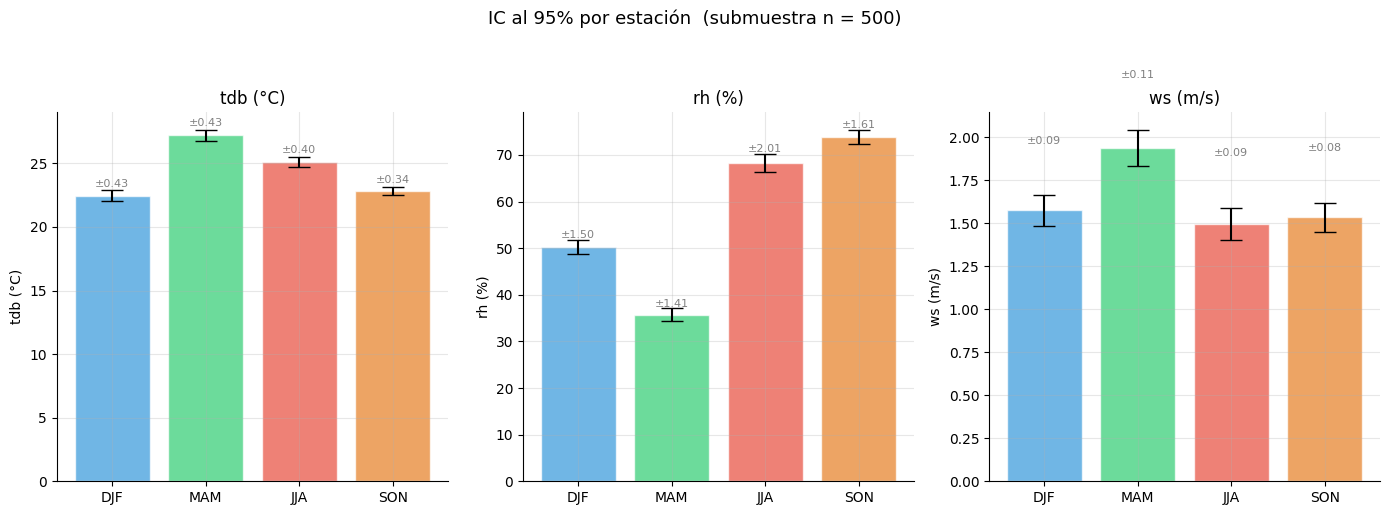

In [9]:
_estaciones = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}
_variables = {"tdb (°C)": tdb, "rh (%)": rh, "ws (m/s)": ws}
_n_sub = 500

fig4, axes4 = plt.subplots(1, 3, figsize=(14, 5))

for ax, (var_name, serie) in zip(axes4, _variables.items()):
    _medias = []
    _errores = []
    _labels = []

    for est_name, meses in _estaciones.items():
        _datos_est = serie[serie.index.month.isin(meses)].values
        _muestra = rng.choice(_datos_est, size=_n_sub, replace=False)
        _xbar = _muestra.mean()
        _s = _muestra.std(ddof=1)
        _se = _s / np.sqrt(_n_sub)
        _t_crit = stats.t.ppf(0.975, _n_sub - 1)
        _margen = _t_crit * _se
        _medias.append(_xbar)
        _errores.append(_margen)
        _labels.append(est_name)

    _x_pos = np.arange(len(_labels))
    ax.bar(
        _x_pos, _medias, yerr=_errores,
        color=["#3498db", "#2ecc71", "#e74c3c", "#e67e22"],
        alpha=0.7, capsize=8, edgecolor="white",
    )
    ax.set_xticks(_x_pos)
    ax.set_xticklabels(_labels)
    ax.set_ylabel(var_name)
    ax.set_title(var_name)

    # Anotar margenes
    for x, m, e in zip(_x_pos, _medias, _errores):
        ax.text(x, m + e + 0.3, f"±{e:.2f}", ha="center",
                fontsize=8, color="gray")

plt.suptitle(
    f"IC al 95% por estación  (submuestra n = {_n_sub})",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

> **Observaciones:**
>
> - **`tdb`:** Diferencias estacionales enormes y clarísimas.
>   JJA (~28–30 °C) vs DJF (~18–20 °C).
> - **`rh`:** También estacional — la humedad relativa es mayor
>   en la temporada de lluvias (JJA/SON).
> - **`ws`:** Las diferencias estacionales son más sutiles.
>   Los ICs de distintas estaciones pueden traslaparse
>   → la diferencia podría no ser significativa.
>
> Cuando los ICs de dos grupos **no se traslapan**, podemos decir
> con confianza que las medias difieren.  Cuando **sí se traslapan**,
> se necesita una prueba formal → eso es el tema de la **semana 6**.

---
## Resumen de la sesión

| Ejercicio | Hallazgo principal |
|:---|:---|
| **IC mensual** | Con ~100k datos por mes, los ICs son ultra-estrechos (±0.01 °C) — el tamaño muestral domina |
| **Efecto de n** | Con $n = 10$, IC de ±2–3 °C; con $n = 1000$, ±0.2 °C — la precisión crece con $\sqrt{n}$ |
| **Cobertura** | ~95% de los ICs al 95% contienen μ, confirmando la teoría incluso con datos no-normales |
| **Por estación** | `tdb` y `rh` muestran diferencias estacionales claras; `ws` es más ambiguo → necesitamos pruebas formales |

**Próxima semana (6):** ¿Cómo formalizar si una diferencia es
"estadísticamente significativa"? **Pruebas de hipótesis.**